<a href="https://colab.research.google.com/github/vidhya2432/Gen-AI/blob/main/Task_3(codedev)_intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1: Predictive Modeling (Classification)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [ ]:
# Load Datasets
train_df = pd.read_csv("/content/churn-bigml-80.csv")
test_df = pd.read_csv("/content/churn-bigml-20.csv")

# Target Variable
target = "Churn"

In [ ]:
# Encode categorical columns
le = LabelEncoder()

for col in train_df.select_dtypes(include='object').columns:
    train_df[col] = le.fit_transform(train_df[col])

for col in test_df.select_dtypes(include='object').columns:
    test_df[col] = le.fit_transform(test_df[col])

In [ ]:
# Features and Target
X_train = train_df.drop(target, axis=1)
y_train = train_df[target]

X_test = test_df.drop(target, axis=1)
y_test = test_df[target]

In [ ]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy: 0.8530734632683659
              precision    recall  f1-score   support

       False       0.88      0.97      0.92       572
        True       0.46      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667



In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy: 0.9175412293853074
              precision    recall  f1-score   support

       False       0.95      0.95      0.95       572
        True       0.70      0.73      0.72        95

    accuracy                           0.92       667
   macro avg       0.83      0.84      0.83       667
weighted avg       0.92      0.92      0.92       667



In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.9460269865067467
              precision    recall  f1-score   support

       False       0.95      0.99      0.97       572
        True       0.95      0.65      0.78        95

    accuracy                           0.95       667
   macro avg       0.95      0.82      0.87       667
weighted avg       0.95      0.95      0.94       667



In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}
Best Accuracy:
0.9527380174406759


#Task 3: NLP – Sentiment Analysis

In [ ]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from wordcloud import WordCloud

In [ ]:
# Download NLTK Resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Load Dataset
df = pd.read_csv("/content/3) Sentiment dataset.csv")

# Display available columns to help identify the text column
print("Available columns in the DataFrame:", df.columns)

# The actual text column in the dataset is 'Text'
text_column = "Text"

Available columns in the DataFrame: Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')


In [ ]:
# Define Text Preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    return " ".join(tokens)

In [ ]:
# Apply Text Preprocessing
df["clean_text"] = df[text_column].apply(preprocess)

In [ ]:
# Define Sentiment Analysis function
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
# Apply Sentiment Analysis
df["Sentiment"] = df["clean_text"].apply(get_sentiment)

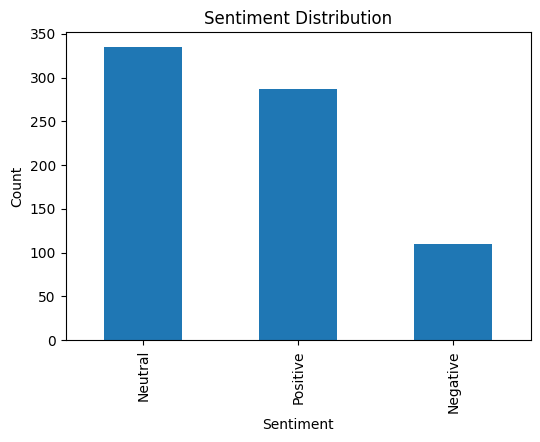

In [ ]:
# Display Sentiment Distribution
plt.figure(figsize=(6,4))
df["Sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

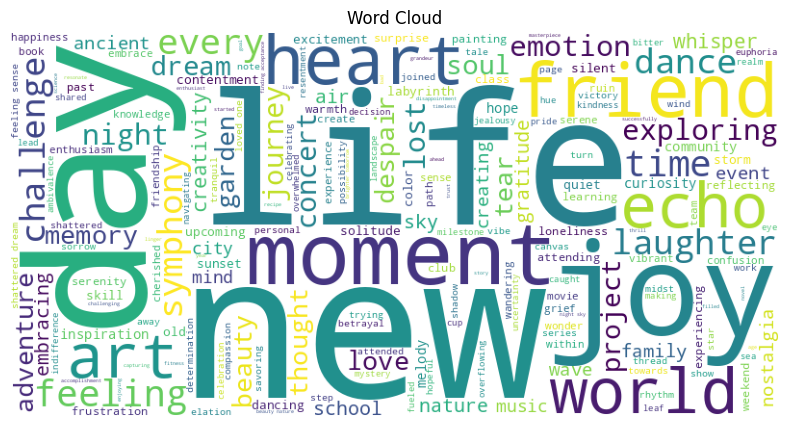

In [ ]:
# Generate and display Word Cloud
text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [ ]:

# Display head of processed data
print(df[["clean_text","Sentiment"]].head())

                         clean_text Sentiment
0       enjoying beautiful day park  Positive
1          traffic terrible morning  Negative
2          finished amazing workout  Positive
3  excited upcoming weekend getaway  Positive
4  trying new recipe dinner tonight  Positive
